# 收盘买入最高价前10转债次日卖出时点分析

目标：基于本地 tick 数据，按“前一日收盘价买入价格最高的 10 只转债”，分析次日 `09:30-09:35` 每 10 秒卖出的收益与可承接成交额，并给出最优卖出区间。

分析口径：
- 选股：每个交易日按 `lastPrice` 最后一个有效成交价排序，取价格最高的 10 只转债。
- 买入价：前一交易日收盘有效成交价。
- 卖出价：次日每个 10 秒窗口内的 `VWAP = 成交额增量 / 成交量增量 / 10`。
- 卖出承接能力：同一 10 秒窗口内的成交额增量。
- 组合收益：每天对 top10 等权平均。


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import date
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# 基础配置：默认覆盖当前本地可用的 2025-2026 转债 tick 数据。
KZZ_PREFIXES = ("110", "111", "113", "118", "123", "127", "128")
TOP_N = 10
BIN_SECONDS = 10
PRICE_SCALE = 10.0
SELL_START = "09:30:00"
SELL_END = "09:35:00"

@dataclass
class Config:
    tick_base: Path = Path("/data1/quant-data/tick_2026")
    output_dir: Path = Path("/data1/code_git/tick_data_analysis/notebook/kzz_top_close_sell_timing_outputs")
    years: tuple[int, ...] = (2025, 2026)

config = Config()
config.output_dir.mkdir(parents=True, exist_ok=True)
config


Config(tick_base=PosixPath('/data1/quant-data/tick_2026'), output_dir=PosixPath('/data1/code_git/tick_data_analysis/notebook/kzz_top_close_sell_timing_outputs'), years=(2025, 2026))

In [2]:
# 下面的函数集中处理数据扫描、10秒分箱、组合收益统计。

def is_kzz_code(code: str) -> bool:
    return code.startswith(KZZ_PREFIXES) and code.endswith((".SH", ".SZ"))

def list_tick_dates(tick_base: Path, years: Sequence[int]) -> List[Tuple[date, Path]]:
    results: List[Tuple[date, Path]] = []
    for year in years:
        year_dir = tick_base / str(year)
        if not year_dir.exists():
            continue
        for month_dir in sorted(year_dir.iterdir()):
            if not month_dir.is_dir() or not month_dir.name.isdigit():
                continue
            for day_dir in sorted(month_dir.iterdir()):
                if not day_dir.is_dir() or not day_dir.name.isdigit():
                    continue
                try:
                    d = date(year, int(month_dir.name), int(day_dir.name))
                except ValueError:
                    continue
                results.append((d, day_dir))
    return sorted(results, key=lambda x: x[0])

def to_local_datetime(time_series: pd.Series) -> pd.Series:
    return pd.to_datetime(time_series, unit="ms", utc=True).dt.tz_convert("Asia/Shanghai").dt.tz_localize(None)

def compute_delta(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce").fillna(0.0)
    delta = numeric.diff()
    if len(delta) > 0:
        delta.iloc[0] = numeric.iloc[0]
    return delta.clip(lower=0.0)

def build_bin_label(bin_index: int) -> str:
    start_seconds = bin_index * BIN_SECONDS
    end_seconds = start_seconds + BIN_SECONDS
    start_total = 9 * 3600 + 30 * 60 + start_seconds
    end_total = 9 * 3600 + 30 * 60 + end_seconds
    sh, sr = divmod(start_total, 3600)
    sm, ss = divmod(sr, 60)
    eh, er = divmod(end_total, 3600)
    em, es = divmod(er, 60)
    return f"{sh:02d}:{sm:02d}:{ss:02d}-{eh:02d}:{em:02d}:{es:02d}"

def get_close_price_from_file(parquet_file: Path) -> float | None:
    try:
        df = pd.read_parquet(parquet_file, columns=["lastPrice"])
    except Exception:
        return None
    if df.empty:
        return None
    trade_price = pd.to_numeric(df["lastPrice"], errors="coerce")
    trade_price = trade_price[trade_price > 0]
    if trade_price.empty:
        return None
    return float(trade_price.iloc[-1])

def get_day_top_close_bonds(day_dir: Path, top_n: int = TOP_N) -> pd.DataFrame:
    rows: List[Dict] = []
    for fp in sorted(day_dir.glob("*.parquet")):
        code = fp.stem
        if not is_kzz_code(code):
            continue
        close_price = get_close_price_from_file(fp)
        if close_price is None:
            continue
        rows.append({"code": code, "buy_price": close_price})
    if not rows:
        return pd.DataFrame(columns=["code", "buy_price"])
    return (
        pd.DataFrame(rows)
        .sort_values(["buy_price", "code"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )

def analyze_next_day_bins(parquet_file: Path, select_date: date, next_date: date, buy_price: float) -> List[Dict]:
    try:
        df = pd.read_parquet(parquet_file, columns=["time", "amount", "volume"])
    except Exception:
        return []
    if df.empty:
        return []

    df = df.sort_values("time").reset_index(drop=True)
    dt = to_local_datetime(df["time"])
    delta_amount = compute_delta(df["amount"])
    delta_volume = compute_delta(df["volume"])

    sell_start = pd.Timestamp(f"{next_date} {SELL_START}")
    sell_end = pd.Timestamp(f"{next_date} {SELL_END}")
    mask = (dt >= sell_start) & (dt < sell_end)

    window = pd.DataFrame({
        "dt": dt[mask],
        "delta_amount": delta_amount[mask],
        "delta_volume": delta_volume[mask],
    })
    if window.empty:
        return []

    window["seconds_since_start"] = (window["dt"] - sell_start).dt.total_seconds().astype(int)
    window = window[(window["seconds_since_start"] >= 0) & (window["seconds_since_start"] < 300)].copy()
    if window.empty:
        return []

    window["bin_index"] = window["seconds_since_start"] // BIN_SECONDS
    grouped = window.groupby("bin_index", as_index=False).agg(
        sell_amount=("delta_amount", "sum"),
        sell_volume=("delta_volume", "sum"),
    )

    rows: List[Dict] = []
    for row in grouped.itertuples(index=False):
        if row.sell_volume <= 0:
            continue
        # amount / volume 得到的是每张价格，转债标准面值按 10 做缩放回报价口径。
        sell_vwap_price = row.sell_amount / row.sell_volume / PRICE_SCALE
        rows.append({
            "select_date": select_date.isoformat(),
            "next_date": next_date.isoformat(),
            "code": parquet_file.stem,
            "buy_price": buy_price,
            "bin_index": int(row.bin_index),
            "bin_label": build_bin_label(int(row.bin_index)),
            "sell_amount": float(row.sell_amount),
            "sell_volume": float(row.sell_volume),
            "sell_vwap_price": float(sell_vwap_price),
            "sell_return": float(sell_vwap_price / buy_price - 1.0) if buy_price > 0 else np.nan,
        })
    return rows

def analyze_all(config: Config) -> Dict[str, pd.DataFrame]:
    tick_dates = list_tick_dates(config.tick_base, config.years)
    if len(tick_dates) < 2:
        raise RuntimeError("可用交易日不足，至少需要两个交易日。")

    selection_rows: List[Dict] = []
    sell_rows: List[Dict] = []

    for idx in range(len(tick_dates) - 1):
        select_date, select_dir = tick_dates[idx]
        next_date, next_dir = tick_dates[idx + 1]
        top_df = get_day_top_close_bonds(select_dir)
        if top_df.empty:
            continue

        selection_rows.extend(
            {
                "select_date": select_date.isoformat(),
                "next_date": next_date.isoformat(),
                "code": row.code,
                "buy_price": float(row.buy_price),
            }
            for row in top_df.itertuples(index=False)
        )

        for row in top_df.itertuples(index=False):
            next_file = next_dir / f"{row.code}.parquet"
            if next_file.exists():
                sell_rows.extend(analyze_next_day_bins(next_file, select_date, next_date, float(row.buy_price)))

        if (idx + 1) % 20 == 0:
            print(f"processed {idx + 1}/{len(tick_dates) - 1} selection days, rows={len(sell_rows)}")

    selection_df = pd.DataFrame(selection_rows)
    sell_df = pd.DataFrame(sell_rows)
    if selection_df.empty or sell_df.empty:
        raise RuntimeError("未生成有效样本。")

    full_bins = pd.DataFrame({"bin_index": np.arange(300 // BIN_SECONDS)})
    full_bins["bin_label"] = full_bins["bin_index"].map(build_bin_label)

    sample_base = selection_df.merge(full_bins, how="cross")
    sample_detail = sample_base.merge(
        sell_df,
        on=["select_date", "next_date", "code", "buy_price", "bin_index", "bin_label"],
        how="left",
    )
    sample_detail["sell_amount"] = sample_detail["sell_amount"].fillna(0.0)
    sample_detail["sell_volume"] = sample_detail["sell_volume"].fillna(0.0)

    sample_summary = sample_detail.groupby(["bin_index", "bin_label"], as_index=False).agg(
        sample_count=("code", "count"),
        trade_count=("sell_amount", lambda s: int((s > 0).sum())),
        mean_return=("sell_return", "mean"),
        median_return=("sell_return", "median"),
        p25_return=("sell_return", lambda s: s.quantile(0.25)),
        p75_return=("sell_return", lambda s: s.quantile(0.75)),
        win_ratio=("sell_return", lambda s: float((s > 0).mean())),
        mean_amount=("sell_amount", "mean"),
        median_amount=("sell_amount", "median"),
        p25_amount=("sell_amount", lambda s: s.quantile(0.25)),
        p75_amount=("sell_amount", lambda s: s.quantile(0.75)),
    )

    daily_portfolio = sample_detail.groupby(["select_date", "next_date", "bin_index", "bin_label"], as_index=False).agg(
        portfolio_return=("sell_return", "mean"),
        portfolio_amount=("sell_amount", "sum"),
        traded_bond_count=("sell_amount", lambda s: int((s > 0).sum())),
    )

    portfolio_summary = daily_portfolio.groupby(["bin_index", "bin_label"], as_index=False).agg(
        day_count=("select_date", "count"),
        mean_portfolio_return=("portfolio_return", "mean"),
        median_portfolio_return=("portfolio_return", "median"),
        p25_portfolio_return=("portfolio_return", lambda s: s.quantile(0.25)),
        p75_portfolio_return=("portfolio_return", lambda s: s.quantile(0.75)),
        mean_portfolio_amount=("portfolio_amount", "mean"),
        median_portfolio_amount=("portfolio_amount", "median"),
        p25_portfolio_amount=("portfolio_amount", lambda s: s.quantile(0.25)),
        p75_portfolio_amount=("portfolio_amount", lambda s: s.quantile(0.75)),
        mean_traded_bond_count=("traded_bond_count", "mean"),
    )

    best_portfolio_bin = portfolio_summary.sort_values(
        ["mean_portfolio_return", "median_portfolio_return"],
        ascending=[False, False],
    ).head(1)
    best_sample_bin = sample_summary.sort_values(
        ["mean_return", "median_return"],
        ascending=[False, False],
    ).head(1)

    overview = pd.DataFrame([
        ("selection_days", selection_df["select_date"].nunique()),
        ("sample_count", len(selection_df)),
        ("best_sample_bin", best_sample_bin.iloc[0]["bin_label"]),
        ("best_sample_mean_return", best_sample_bin.iloc[0]["mean_return"]),
        ("best_sample_mean_amount", best_sample_bin.iloc[0]["mean_amount"]),
        ("best_portfolio_bin", best_portfolio_bin.iloc[0]["bin_label"]),
        ("best_portfolio_mean_return", best_portfolio_bin.iloc[0]["mean_portfolio_return"]),
        ("best_portfolio_mean_amount", best_portfolio_bin.iloc[0]["mean_portfolio_amount"]),
    ], columns=["metric", "value"])

    return {
        "selection": selection_df,
        "sample_detail": sample_detail.sort_values(["select_date", "code", "bin_index"]).reset_index(drop=True),
        "sample_summary": sample_summary.sort_values("bin_index").reset_index(drop=True),
        "daily_portfolio": daily_portfolio.sort_values(["select_date", "bin_index"]).reset_index(drop=True),
        "portfolio_summary": portfolio_summary.sort_values("bin_index").reset_index(drop=True),
        "overview": overview,
    }


In [3]:
# 主分析单元：执行全量统计，并把结果保存为 CSV，便于后续复查。
results = analyze_all(config)

for name, df in results.items():
    df.to_csv(config.output_dir / f"{name}.csv", index=False)

overview = results["overview"]
sample_summary = results["sample_summary"]
portfolio_summary = results["portfolio_summary"]
daily_portfolio = results["daily_portfolio"]
sample_detail = results["sample_detail"]

overview


processed 20/145 selection days, rows=5878
processed 40/145 selection days, rows=11817
processed 60/145 selection days, rows=17577
processed 80/145 selection days, rows=23561
processed 100/145 selection days, rows=29529
processed 120/145 selection days, rows=35468
processed 140/145 selection days, rows=40832


,metric,value
0,selection_days,143
1,sample_count,1430
2,best_sample_bin,09:30:00-09:30:10
3,best_sample_mean_return,0.003067
4,best_sample_mean_amount,5857931.547552
5,best_portfolio_bin,09:30:00-09:30:10
6,best_portfolio_mean_return,0.00309
7,best_portfolio_mean_amount,58579315.475524


In [4]:
# 关键结论：优先看组合维度，因为它直接对应“每天持有 top10 一起卖出”。
best_portfolio = portfolio_summary.sort_values(
    ["mean_portfolio_return", "median_portfolio_return"],
    ascending=[False, False],
).head(10)

best_sample = sample_summary.sort_values(
    ["mean_return", "median_return"],
    ascending=[False, False],
).head(10)

display(best_portfolio)
display(best_sample)

best_bin_label = best_portfolio.iloc[0]["bin_label"]
best_daily = daily_portfolio[daily_portfolio["bin_label"] == best_bin_label].copy()

best_bin_stats = pd.DataFrame([
    ("best_bin", best_bin_label),
    ("mean_portfolio_return", best_daily["portfolio_return"].mean()),
    ("median_portfolio_return", best_daily["portfolio_return"].median()),
    ("p25_portfolio_return", best_daily["portfolio_return"].quantile(0.25)),
    ("p75_portfolio_return", best_daily["portfolio_return"].quantile(0.75)),
    ("mean_portfolio_amount", best_daily["portfolio_amount"].mean()),
    ("median_portfolio_amount", best_daily["portfolio_amount"].median()),
    ("p25_portfolio_amount", best_daily["portfolio_amount"].quantile(0.25)),
    ("p75_portfolio_amount", best_daily["portfolio_amount"].quantile(0.75)),
    ("mean_traded_bond_count", best_daily["traded_bond_count"].mean()),
], columns=["metric", "value"])

best_bin_stats


,bin_index,bin_label,day_count,mean_portfolio_return,median_portfolio_return,p25_portfolio_return,p75_portfolio_return,mean_portfolio_amount,median_portfolio_amount,p25_portfolio_amount,p75_portfolio_amount,mean_traded_bond_count
0,0,09:30:00-09:30:10,143,0.003090,0.003086,-0.000728,0.007493,5.857932e+07,53075763.0,39900440.0,71291521.5,9.734266
26,26,09:34:20-09:34:30,143,0.003023,0.003849,-0.003046,0.010172,2.037610e+07,17905084.0,13796230.0,24198333.0,9.692308
25,25,09:34:10-09:34:20,143,0.002980,0.003478,-0.003888,0.009938,2.260442e+07,21138546.0,14953411.5,27347538.5,9.734266
27,27,09:34:30-09:34:40,143,0.002880,0.003784,-0.003438,0.009722,2.354605e+07,22386145.0,14997425.0,29585743.0,9.734266
3,3,09:30:30-09:30:40,143,0.002879,0.002843,-0.002274,0.008519,3.765428e+07,37376874.0,27400489.5,43562939.0,9.734266
2,2,09:30:20-09:30:30,143,0.002859,0.002772,-0.002321,0.008494,2.886289e+07,27153650.0,20698695.0,34521425.0,9.734266
1,1,09:30:10-09:30:20,143,0.002835,0.002978,-0.001820,0.008112,3.023482e+07,28147638.0,20756651.5,38452236.5,9.734266
28,28,09:34:40-09:34:50,143,0.002813,0.003605,-0.003541,0.009781,1.894993e+07,16687484.0,11908892.0,24512778.0,9.713287
29,29,09:34:50-09:35:00,143,0.002772,0.003372,-0.003882,0.010083,1.832762e+07,16891947.0,11788231.0,23416374.0,9.706294
24,24,09:34:00-09:34:10,143,0.002731,0.002718,-0.003422,0.009831,2.851393e+07,26756304.0,18655415.0,34995774.0,9.734266


,bin_index,bin_label,sample_count,trade_count,mean_return,median_return,p25_return,p75_return,win_ratio,mean_amount,median_amount,p25_amount,p75_amount
0,0,09:30:00-09:30:10,1430,1392,0.003067,0.001228,-0.003273,0.007113,0.565734,5.857932e+06,2883626.5,1378581.25,5957572.50
26,26,09:34:20-09:34:30,1430,1386,0.002981,0.001687,-0.008126,0.011108,0.534266,2.037610e+06,914615.0,374060.75,2256254.25
25,25,09:34:10-09:34:20,1430,1392,0.002935,0.001603,-0.007973,0.011044,0.539161,2.260442e+06,1072284.0,460041.75,2459870.75
3,3,09:30:30-09:30:40,1430,1392,0.002837,0.001110,-0.005508,0.009195,0.530769,3.765428e+06,2052121.0,973099.00,4244718.50
27,27,09:34:30-09:34:40,1430,1392,0.002834,0.001511,-0.008355,0.011034,0.528671,2.354605e+06,1097477.0,461710.75,2549331.00
2,2,09:30:20-09:30:30,1430,1392,0.002823,0.000938,-0.005373,0.008754,0.534965,2.886289e+06,1618955.0,774073.50,3381517.00
1,1,09:30:10-09:30:20,1430,1392,0.002805,0.000713,-0.004831,0.007684,0.523776,3.023482e+06,1642549.0,766063.75,3550614.75
28,28,09:34:40-09:34:50,1430,1389,0.002770,0.001516,-0.008366,0.011166,0.530769,1.894993e+06,796122.5,322557.75,2040869.00
29,29,09:34:50-09:35:00,1430,1388,0.002705,0.001429,-0.008418,0.011122,0.528671,1.832762e+06,800482.0,314160.50,1916487.75
24,24,09:34:00-09:34:10,1430,1392,0.002686,0.001332,-0.008181,0.010970,0.527972,2.851393e+06,1242748.5,577928.25,3106736.00


,metric,value
0,best_bin,09:30:00-09:30:10
1,mean_portfolio_return,0.00309
2,median_portfolio_return,0.003086
3,p25_portfolio_return,-0.000728
4,p75_portfolio_return,0.007493
5,mean_portfolio_amount,58579315.475524
6,median_portfolio_amount,53075763.0
7,p25_portfolio_amount,39900440.0
8,p75_portfolio_amount,71291521.5
9,mean_traded_bond_count,9.734266


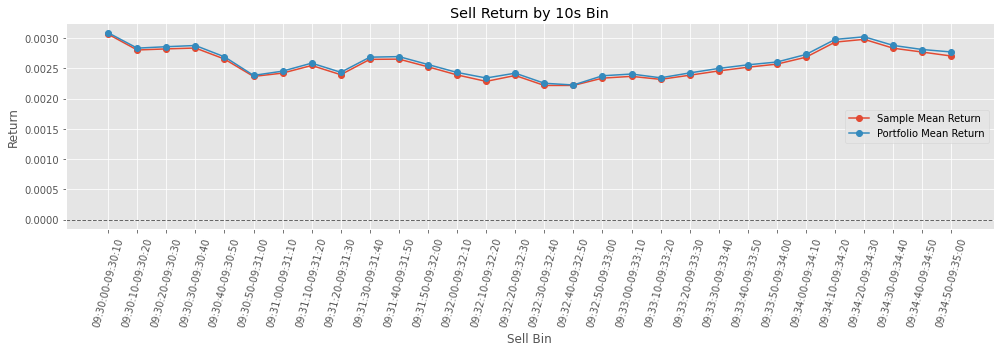

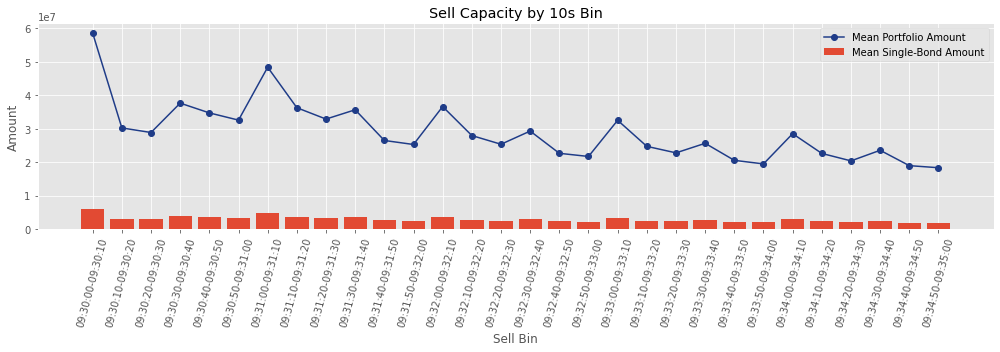

In [5]:
# 图形化展示：收益最优时段与成交额容量是否一致。
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_summary["bin_label"], sample_summary["mean_return"], marker="o", label="Sample Mean Return")
ax.plot(portfolio_summary["bin_label"], portfolio_summary["mean_portfolio_return"], marker="o", label="Portfolio Mean Return")
ax.axhline(0.0, color="#666", linestyle="--", linewidth=1)
ax.set_title("Sell Return by 10s Bin")
ax.set_xlabel("Sell Bin")
ax.set_ylabel("Return")
ax.tick_params(axis="x", rotation=75)
ax.legend()
fig.tight_layout()
fig.savefig(config.output_dir / "sell_return_by_bin.png", dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sample_summary["bin_label"], sample_summary["mean_amount"], label="Mean Single-Bond Amount")
ax.plot(portfolio_summary["bin_label"], portfolio_summary["mean_portfolio_amount"], color="#1f3c88", marker="o", label="Mean Portfolio Amount")
ax.set_title("Sell Capacity by 10s Bin")
ax.set_xlabel("Sell Bin")
ax.set_ylabel("Amount")
ax.tick_params(axis="x", rotation=75)
ax.legend()
fig.tight_layout()
fig.savefig(config.output_dir / "sell_amount_by_bin.png", dpi=150)
plt.show()
plt.close(fig)


,select_date,next_date,portfolio_return,portfolio_amount,traded_bond_count
0,2025-07-31,2025-08-01,0.005902,32470752.0,6
30,2025-08-01,2025-08-04,-0.001274,53514257.0,10
60,2025-08-04,2025-08-05,0.007493,54623772.0,10
90,2025-08-05,2025-08-06,0.002874,57517571.0,10
120,2025-08-06,2025-08-07,0.004834,68803723.0,10
150,2025-08-07,2025-08-08,-0.000728,50674243.0,10
180,2025-08-08,2025-08-11,0.007220,78518507.0,10
210,2025-08-11,2025-08-12,-0.001893,37230472.0,10
240,2025-08-12,2025-08-13,0.006024,57886193.0,10
270,2025-08-13,2025-08-14,0.005070,54972940.0,10


,select_date,next_date,code,buy_price,bin_index,bin_label,sell_amount,sell_volume,sell_vwap_price,sell_return
0,2025-07-31,2025-08-01,110060.SH,485.984,0,09:30:00-09:30:10,0.0,0.0,NaN,NaN
1,2025-07-31,2025-08-01,110060.SH,485.984,1,09:30:10-09:30:20,0.0,0.0,NaN,NaN
2,2025-07-31,2025-08-01,110060.SH,485.984,2,09:30:20-09:30:30,0.0,0.0,NaN,NaN
3,2025-07-31,2025-08-01,110060.SH,485.984,3,09:30:30-09:30:40,0.0,0.0,NaN,NaN
4,2025-07-31,2025-08-01,110060.SH,485.984,4,09:30:40-09:30:50,0.0,0.0,NaN,NaN
5,2025-07-31,2025-08-01,110060.SH,485.984,5,09:30:50-09:31:00,0.0,0.0,NaN,NaN
6,2025-07-31,2025-08-01,110060.SH,485.984,6,09:31:00-09:31:10,0.0,0.0,NaN,NaN
7,2025-07-31,2025-08-01,110060.SH,485.984,7,09:31:10-09:31:20,0.0,0.0,NaN,NaN
8,2025-07-31,2025-08-01,110060.SH,485.984,8,09:31:20-09:31:30,0.0,0.0,NaN,NaN
9,2025-07-31,2025-08-01,110060.SH,485.984,9,09:31:30-09:31:40,0.0,0.0,NaN,NaN


输出目录: /data1/code_git/tick_data_analysis/notebook/kzz_top_close_sell_timing_outputs


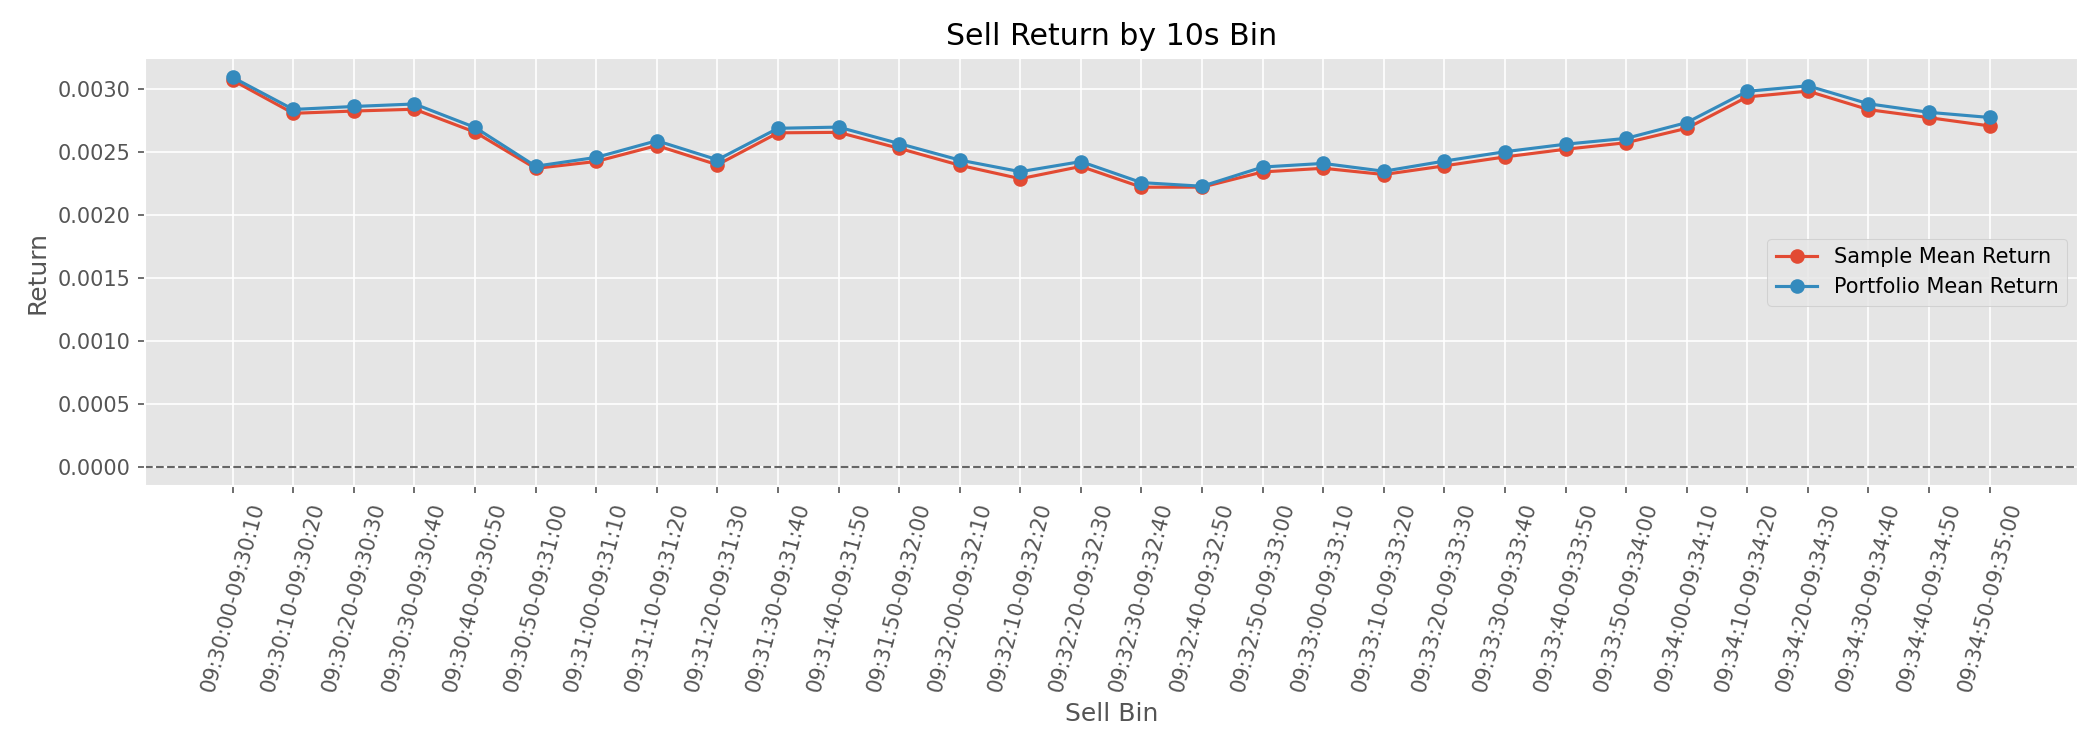

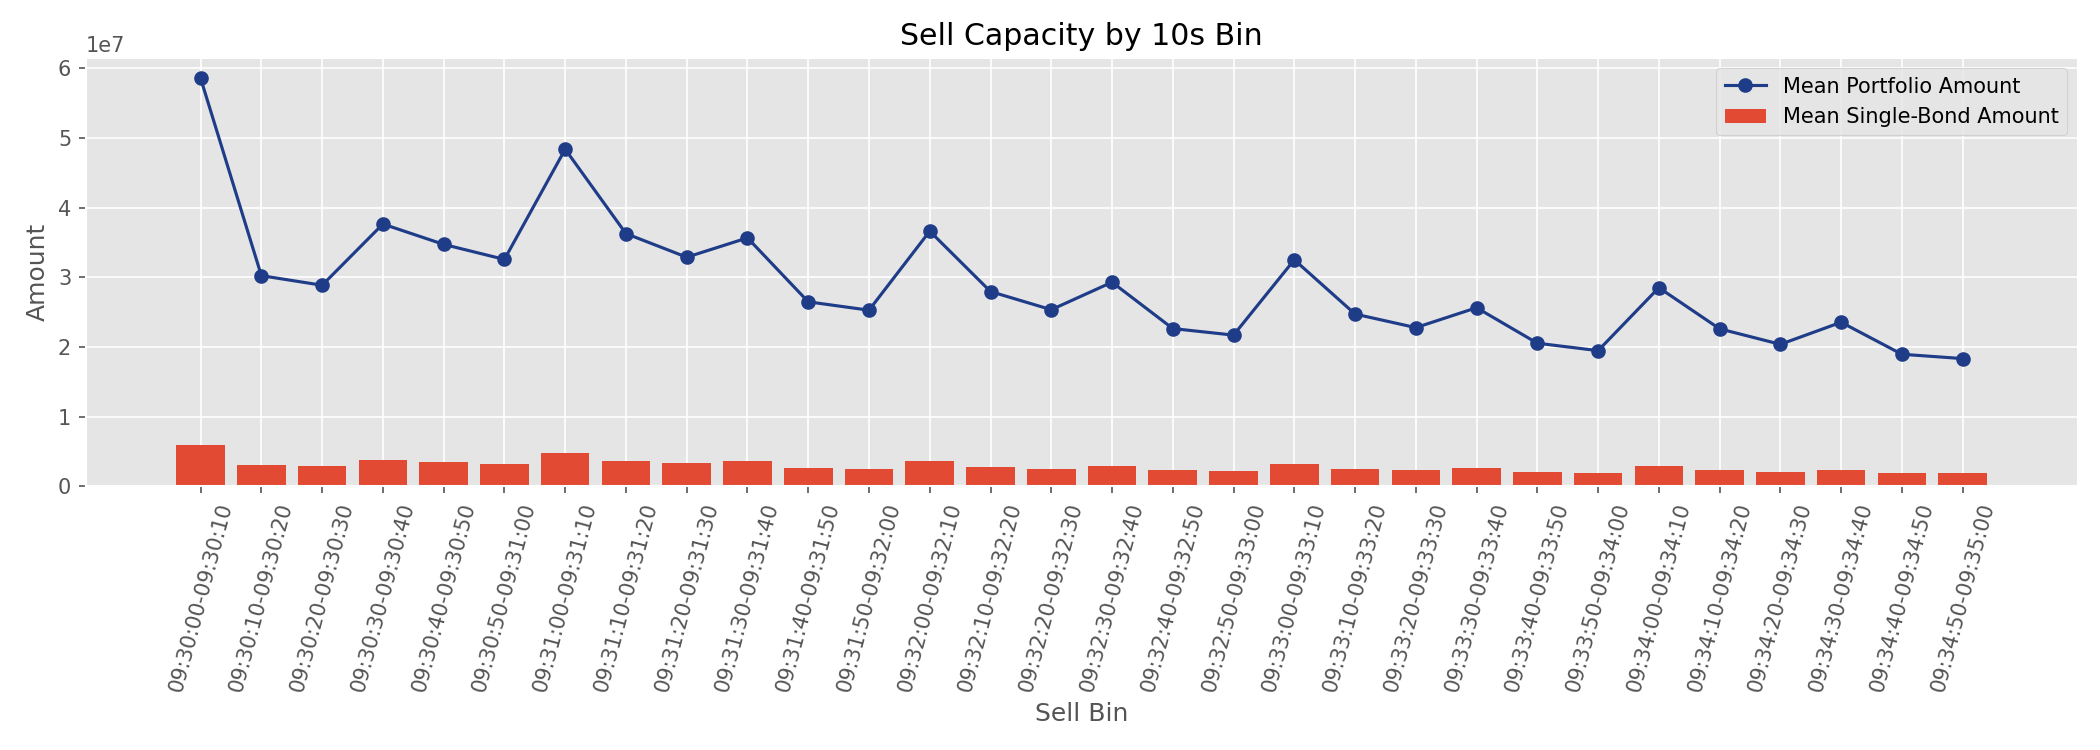

In [6]:
# 明细补充：查看最优卖出区间在逐日层面的收益分布和容量分布。
display(best_daily[[
    "select_date", "next_date", "portfolio_return", "portfolio_amount", "traded_bond_count"
]].head(20))

display(sample_detail.head(20))

print("输出目录:", config.output_dir)
for fn in ["sell_return_by_bin.png", "sell_amount_by_bin.png"]:
    display(Image(filename=str(config.output_dir / fn)))
